<a href="https://colab.research.google.com/github/YashviGupta15/ai-ml-notes/blob/main/CNN_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SECTION 1 — Why Fully Connected Networks Fail for Images

Before CNNs, let us ask:

Can we directly use a Fully Connected Network (ANN) for images?

We already know the ANN pipeline:

Flatten → Linear → Activation → Repeat

Let us test this idea carefully.

## Example: Small RGB Image

Consider a small RGB image:

Height = 32  
Width = 32  
Channels = 3  

Total number of input features:

$$
32 \times 32 \times 3 = 3072
$$

Now suppose we connect this to just 100 hidden neurons.

Total weight parameters:

$$
3072 \times 100 = 307,200
$$

Plus 100 bias terms.

That is already **~300K parameters in just ONE layer**.

In [ ]:
# Parameter explosion demonstration

H, W, C = 32, 32, 3
hidden_neurons = 100

input_features = H * W * C
params = input_features * hidden_neurons + hidden_neurons

print("Input features:", input_features)
print("Parameters in first fully connected layer:", params)

Input features: 3072
Parameters in first fully connected layer: 307300


## What If Image Size Increases?

If image size becomes:

$$
128 \times 128 \times 3
$$

Then input features:

$$
128 \times 128 \times 3 = 49,152
$$

Connecting to 100 neurons:

$$
49,152 \times 100 = 4,915,200
$$

Almost **5 million parameters in just one layer**.

This grows extremely fast.

## Problem 1 — Parameter Explosion

Large parameter count leads to:

- High memory consumption
- Slower computation
- Higher risk of overfitting
- Difficult training

Images are large structured objects.

Fully connected layers treat them as long vectors.

## Problem 2 — Loss of Spatial Structure

When we flatten the image:

$$
(H, W, C) \rightarrow (H \times W \times C)
$$

We destroy spatial relationships.

Example:

Two neighboring pixels in the grid  
may become far apart in the vector.

ANN does NOT know:

- Which pixels were neighbors
- Which pixels formed edges
- Which pixels formed shapes

But images are not random vectors.
They are structured spatial signals.

## Key Insight

Images contain:

- Local patterns
- Repeated structures
- Spatial hierarchy

We need a model that:

- Preserves locality
- Reuses patterns
- Uses fewer parameters

This motivates Convolutional Neural Networks.

### Concept Check — Section 1

1. If image height and width double, how does parameter count change in a fully connected layer?

2. Does flattening preserve spatial adjacency information? Why or why not?

3. Why can large parameter counts increase overfitting risk?

4. Is the problem mainly computational, statistical, or both?

5. What structural property of images is ignored by fully connected networks?

# SECTION 2 — Images as Tensors

Before we apply convolution, we must understand:

How exactly is an image represented mathematically?

In CNNs, images are not vectors.
They are multi-dimensional tensors.

Let us build this understanding step by step.

## What is a Pixel?

A pixel is a numerical value.

For a grayscale image:
- Each pixel has 1 intensity value.

For an RGB image:
- Each pixel has 3 values:
  - Red
  - Green
  - Blue

So a color image is not 2D — it is 3D.

## Image as a 3D Tensor

An RGB image can be represented as:

$$
(H, W, C)
$$

Where:
- H = Height
- W = Width
- C = Channels (3 for RGB)

Example:

32 × 32 RGB image → (32, 32, 3)

This is a 3D tensor.

In [ ]:
import torch

# Create a single RGB image
image = torch.randn(32, 32, 3)  # (H, W, C)

print("Image shape (H, W, C):", image.shape)

Image shape (H, W, C): torch.Size([32, 32, 3])


## PyTorch Tensor Convention

PyTorch uses a different ordering:

$$
(N, C, H, W)
$$

Where:
- N = Batch size
- C = Channels
- H = Height
- W = Width

For a single RGB image:

(1, 3, 32, 32)

For 10 images:

(10, 3, 32, 32)

This ordering is important for convolution layers.

In [ ]:
# Single image in PyTorch format
image_pt = torch.randn(1, 3, 32, 32)

print("PyTorch image shape (N, C, H, W):", image_pt.shape)

# Batch of 5 images
batch = torch.randn(5, 3, 32, 32)
print("Batch shape:", batch.shape)

PyTorch image shape (N, C, H, W): torch.Size([1, 3, 32, 32])
Batch shape: torch.Size([5, 3, 32, 32])


## Why is Channel Before Height and Width?

In convolution:

- Each filter operates across ALL channels.
- Channel dimension is treated as depth.
- Convolution slides only across height and width.

So the structure is:

Depth (Channels)  
→ Spatial dimensions (Height, Width)

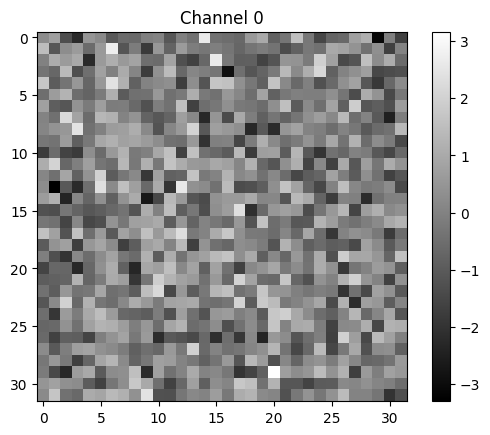

Tensor shape: torch.Size([3, 32, 32])


In [ ]:
import matplotlib.pyplot as plt

# Create simple random image
img = torch.randn(3, 32, 32)

# Visualize first channel
plt.imshow(img[2], cmap='gray')
plt.title("Channel 0")
plt.colorbar()
plt.show()

print("Tensor shape:", img.shape)

### Concept Check — Section 2

1. What is the tensor shape of a grayscale image in PyTorch format?

2. If we have 20 RGB images of size 64×64, what is the full tensor shape in PyTorch?

3. Why does convolution operate across channels but slide only across height and width?

4. What role does the batch dimension (N) play during training?

5. If we remove the batch dimension, what potential issues arise?

# SECTION 3 — Convolution (Intuition First)

We identified two problems with fully connected layers:

1. Too many parameters  
2. Loss of spatial structure  

Now the key question:

How can we process an image WITHOUT flattening it?

The answer is: Convolution.

Convolution works locally and preserves spatial structure.

## The Sliding Window Idea

Imagine placing a small square window on the image.

Example:
A 3 × 3 window.

We:
- Look at a small local patch
- Compute something from it
- Move the window slightly
- Repeat

This sliding operation produces a new image.

This small window is called a **Kernel** (or Filter).

## What Happens at One Location?

At each position:

1. Take the 3 × 3 image patch
2. Multiply element-wise with kernel
3. Sum all values

This produces ONE number.

That number becomes a pixel in the output image.

Then the window slides to the next location.

In [ ]:
import torch

# Example 3x3 image patch
patch = torch.tensor([
    [1., 2., 1.],
    [0., 1., 0.],
    [2., 1., 2.]
])

# Example kernel (vertical edge detector style)
kernel = torch.tensor([
    [1., 0., -1.],
    [1., 0., -1.],
    [1., 0., -1.]
])

result = (patch * kernel).sum()

print("Patch:\n", patch)
print("\nKernel:\n", kernel)
print("\nConvolution result at this location:", result.item())

Patch:
 tensor([[1., 2., 1.],
        [0., 1., 0.],
        [2., 1., 2.]])

Kernel:
 tensor([[ 1.,  0., -1.],
        [ 1.,  0., -1.],
        [ 1.,  0., -1.]])

Convolution result at this location: 0.0


## Interpretation

The kernel acts as a pattern detector.

Example:

If the kernel is:

[ 1  0 -1  
  1  0 -1  
  1  0 -1 ]

It detects vertical edges.

Why?

Because:
- Left side gets positive weight
- Right side gets negative weight

If there is a strong intensity difference,
the output becomes large.

In [ ]:
import torch.nn.functional as F

# Create a small 5x5 image
image = torch.randn(1, 1, 5, 5)

# Create 3x3 kernel
kernel = torch.randn(1, 1, 4, 4)

output = F.conv2d(image, kernel)

print("Input shape:", image.shape)
print("Kernel shape:", kernel.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([1, 1, 5, 5])
Kernel shape: torch.Size([1, 1, 4, 4])
Output shape: torch.Size([1, 1, 2, 2])


## Why Does Output Become Smaller?

If input is:

5 × 5

And kernel is:

3 × 3

The kernel cannot slide beyond boundaries.

So output size becomes:

$$
5 - 3 + 1 = 3
$$

So output becomes:

3 × 3

### Concept Check — Section 3

1. Why does convolution preserve spatial structure?

2. What is the role of the kernel?

3. Why does output size shrink when no padding is used?

4. If the kernel size increases, what happens to output size?

5. Is convolution a global or local operation?

# SECTION 4 — Convolution as a Linear Operation

In the previous section, we saw:

At each location:
- Multiply image patch with kernel
- Sum the result

This looks familiar.

It is simply a dot product.

Let us formalize this carefully.

## Convolution at One Location

Suppose:

- Image patch size = 3 × 3
- Kernel size = 3 × 3

Flatten both into vectors of size 9.

Then:

$$
\text{Output} = \mathbf{w}^T \mathbf{x}
$$

Where:
- $\mathbf{x}$ = flattened image patch
- $\mathbf{w}$ = flattened kernel

This is exactly a linear transformation.

In [ ]:
import torch

patch = torch.randn(3, 3)
kernel = torch.randn(3, 3)

# Flatten
x = patch.view(-1)
w = kernel.view(-1)

dot_result = torch.dot(w, x)
manual_result = (patch * kernel).sum()

print("Dot product result:", dot_result.item())
print("Elementwise-sum result:", manual_result.item())

Dot product result: -7.203881740570068
Elementwise-sum result: -7.203881740570068


## Linearity of Convolution

A transformation T is linear if:

$$
T(a x_1 + b x_2) = a T(x_1) + b T(x_2)
$$

Since convolution at each location is a dot product,
and dot product is linear,

Convolution is a linear operation.

In [ ]:
import torch
import torch.nn.functional as F

x1 = torch.randn(1, 1, 5, 5)
x2 = torch.randn(1, 1, 5, 5)
kernel = torch.randn(1, 1, 3, 3)

a, b = 2.0, -1.5

left = F.conv2d(a*x1 + b*x2, kernel)
right = a*F.conv2d(x1, kernel) + b*F.conv2d(x2, kernel)

print("Difference (should be near 0):",
      torch.abs(left - right).sum().item())

Difference (should be near 0): 4.0531158447265625e-06


## The Important Difference from Fully Connected Layers

In a fully connected layer:

Every output neuron has its own weights.

In convolution:

The SAME kernel is reused at every spatial location.

This is called:

Weight Sharing.

Implication:

Instead of learning separate weights for each pixel position,
we assume the same pattern can appear anywhere.

## Parameter Comparison

Fully Connected (32 × 32 × 3 → 100 neurons):

$$
3072 \times 100 \approx 300K \text{ parameters}
$$

Single 3 × 3 kernel:

$$
3 \times 3 = 9 \text{ parameters}
$$

Even with 10 filters:

$$
10 \times 9 = 90 \text{ parameters}
$$

This is a massive reduction.

### Concept Check — Section 4

1. Why is convolution considered a linear operation?

2. What assumption does weight sharing encode about images?

3. How does weight sharing reduce overfitting risk?

4. What is the key mathematical difference between convolution and fully connected layers?

5. If we remove weight sharing, what would happen to parameter count?

# SECTION 5 — Stride and Padding

So far:

- Kernel slides across image
- Output becomes smaller

Now two important questions:

1. How far does the kernel move each step?
2. Can we control output size?

These are controlled by:

- Stride
- Padding

## Stride (S)

Stride tells us:

How many pixels the kernel moves at each step.

If:

S = 1 → Move 1 pixel (default)
S = 2 → Move 2 pixels (skip one)
S = 3 → Move 3 pixels

Larger stride →
- Fewer sliding positions
- Smaller output
- Faster computation

In [ ]:
import torch
import torch.nn as nn

x = torch.randn(1, 1, 8, 8)

conv_s1 = nn.Conv2d(1, 1, kernel_size=3, stride=1)
conv_s2 = nn.Conv2d(1, 1, kernel_size=3, stride=2)

out_s1 = conv_s1(x)
out_s2 = conv_s2(x)

print("Input shape:", x.shape)
print("Output shape (stride=1):", out_s1.shape)
print("Output shape (stride=2):", out_s2.shape)

Input shape: torch.Size([1, 1, 8, 8])
Output shape (stride=1): torch.Size([1, 1, 6, 6])
Output shape (stride=2): torch.Size([1, 1, 3, 3])


## Padding (P)

Without padding:
- Kernel cannot go beyond image boundary
- Output shrinks

Padding adds zeros around border.

Why?

- Preserve spatial size
- Retain boundary information
- Control shrinking rate

Padding is usually symmetric.

In [ ]:
# Padding example

conv_no_pad = nn.Conv2d(1, 1, kernel_size=3, padding=0)
conv_pad = nn.Conv2d(1, 1, kernel_size=3, padding=5 ,stride =2)

out_no_pad = conv_no_pad(x)
out_pad = conv_pad(x)

print("Output without padding:", out_no_pad.shape)
print("Output with padding=1:", out_pad.shape)

Output without padding: torch.Size([1, 1, 6, 6])
Output with padding=1: torch.Size([1, 1, 8, 8])


## Output Size Formula

For one spatial dimension:

$$
\text{Output Size} =
\frac{W - F + 2P}{S} + 1
$$

Where:

- W = Input width
- F = Filter size
- P = Padding
- S = Stride

This formula applies to height and width separately.

In [ ]:
# Validate formula numerically

W = 8
F = 3
P = 1
S = 2

computed_output = (W - F + 2*P)//S + 1
print("Formula output size:", computed_output)

conv_test = nn.Conv2d(1, 1, kernel_size=F, stride=S, padding=P)
out = conv_test(x)

print("Actual output size:", out.shape[-1])

Formula output size: 4
Actual output size: 4


## Interpretation

Increasing Stride:
- Reduces spatial resolution
- Acts like downsampling

Increasing Padding:
- Preserves border information
- Can keep output size equal to input

Special case:

If:
F = 3
P = 1
S = 1

Then output size = input size.

### Concept Check — Section 5

1. If stride increases, what happens to output size?

2. Why might we want to use padding?

3. For input size 10, kernel size 3, stride 1, padding 0:
   What is output size?

4. If padding is too large, what could happen?

5. Does stride affect parameter count?

# SECTION 6 — Multiple Filters and Feature Maps

So far:

- One kernel → One feature map

But detecting only one pattern is not enough.

Images contain:
- Edges
- Corners
- Textures
- Color transitions

So we use multiple filters.

## One Filter → One Feature Map

If:

Input shape:
(N, C, H, W)

We apply:

1 filter of size (C, F, F)

Output shape becomes:

(N, 1, H', W')

Where H' and W' depend on stride and padding.

## Multiple Filters

If we use:

K filters

Each filter produces:

One feature map.

So output depth becomes:

K

Final output shape:

(N, K, H', W')

In [ ]:
import torch
import torch.nn as nn

# Input batch: 2 RGB images
x = torch.randn(2, 3, 32, 32)

# 5 filters
conv = nn.Conv2d(
    in_channels=3,
    out_channels=5,
    kernel_size=3,
    stride=1,
    padding=1
)

out = conv(x)

print("Input shape:", x.shape)
print("Output shape:", out.shape)

Input shape: torch.Size([2, 3, 32, 32])
Output shape: torch.Size([2, 5, 32, 32])


## Shape Reasoning Step-by-Step

Input:
(N, C, H, W)

Filter:
(K filters, each of shape C × F × F)

Output:
(N, K, H', W')

Important:

Each filter spans ALL input channels.

For RGB input (C = 3):

Each filter has depth = 3.

So kernel shape is:

(3, F, F)

## Parameter Count

If:

C = 3  
F = 3  
K = 5  

Each filter parameters:

$$
3 \times 3 \times 3 = 27
$$

Total parameters:

$$
27 \times 5 = 135
$$

Plus 5 bias terms.

Still extremely small compared to fully connected layers.

### Concept Check — Section 6

1. What determines the depth (number of channels) of the output?

2. Does each filter operate on a single input channel or all channels?

3. If input shape is (10, 3, 64, 64) and we use 16 filters,
   what is the output depth?

4. If we double the number of filters,
   what happens to parameter count?

5. Why is using multiple filters important?

# SECTION 7 — Pooling

After convolution:

- Depth increases (more feature maps)
- Spatial size may remain large

If we keep stacking convolutions:
- Computation increases
- Memory increases

We need a way to reduce spatial size
while keeping important information.

This is where Pooling comes in.

## Max Pooling (Intuition)

Most common pooling: Max Pooling.

Example:
2 × 2 window with stride 2.

Process:
- Divide feature map into small blocks
- Take the maximum value in each block

This reduces height and width by half.

It keeps the strongest activation.

In [ ]:
import torch
import torch.nn as nn

# Create dummy feature map
x = torch.randn(1, 3, 32, 32)

pool = nn.MaxPool2d(kernel_size=2, stride=2)

out = pool(x)

print("Before pooling:", x.shape)
print("After pooling:", out.shape)

Before pooling: torch.Size([1, 3, 32, 32])
After pooling: torch.Size([1, 3, 16, 16])


## Small Numeric Example

Suppose feature map:

$$
\begin{bmatrix}
1 & 5 \\
2 & 3
\end{bmatrix}
$$

2×2 max pooling →

Output:

$$
5
$$

It selects the strongest activation.

## Why Pooling Works

Pooling introduces:

1. Spatial reduction  
2. Translation tolerance  

If an edge shifts slightly,
max pooling may still capture it.

This gives a small degree of invariance.

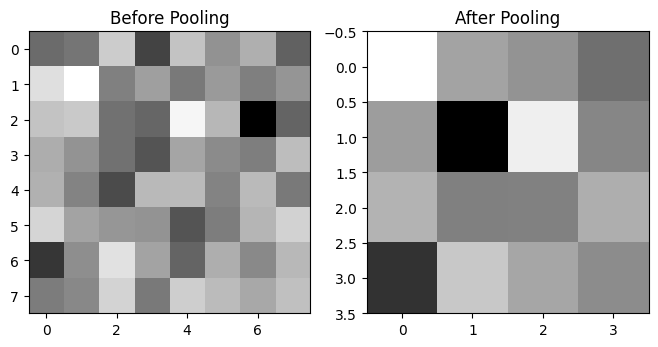

Before: torch.Size([1, 1, 8, 8])
After: torch.Size([1, 1, 4, 4])


In [ ]:
import matplotlib.pyplot as plt

# Use single-channel example for visualization
x_single = torch.randn(1, 1, 8, 8)
pool = nn.MaxPool2d(2, 2)

out_single = pool(x_single)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(x_single[0,0], cmap='gray')
plt.title("Before Pooling")

plt.subplot(1,2,2)
plt.imshow(out_single[0,0], cmap='gray')
plt.title("After Pooling")

plt.show()

print("Before:", x_single.shape)
print("After:", out_single.shape)

## Shape Flow Through Pooling

Input:
(N, C, H, W)

After 2×2 pooling (stride 2):

(N, C, H/2, W/2)

Important:

Pooling does NOT change depth.
It only reduces spatial dimensions.

### Concept Check — Section 7

1. Does pooling change the number of channels?

2. Why does max pooling introduce translation tolerance?

3. If input is (8, 16, 64, 64),
   what is output shape after 2×2 pooling?

4. Does pooling add trainable parameters?

5. What information might pooling discard?

# SECTION 8 — Minimal CNN Block

We now combine:

1. Convolution (feature extraction)
2. ReLU (non-linearity)
3. Pooling (spatial reduction)

This forms the fundamental building block of CNNs.

Conv → ReLU → Pool

## Role of Each Component

Convolution:
- Linear transformation
- Detects patterns
- Increases depth

ReLU:
- Introduces non-linearity
- Enables complex feature learning

Pooling:
- Reduces spatial size
- Improves computational efficiency

In [ ]:
import torch
import torch.nn as nn

class SimpleCNNBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels=3,
            out_channels=8,
            kernel_size=3,
            padding=1
        )
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        print("Input shape:", x.shape)

        x = self.conv(x)
        print("After Conv:", x.shape)

        x = self.relu(x)
        print("After ReLU:", x.shape)

        x = self.pool(x)
        print("After Pool:", x.shape)

        return x

In [ ]:
model = SimpleCNNBlock()

dummy_input = torch.randn(1, 3, 32, 32)

output = model(dummy_input)

print("Final output shape:", output.shape)

Input shape: torch.Size([1, 3, 32, 32])
After Conv: torch.Size([1, 8, 32, 32])
After ReLU: torch.Size([1, 8, 32, 32])
After Pool: torch.Size([1, 8, 16, 16])
Final output shape: torch.Size([1, 8, 16, 16])


## Shape Flow Explanation

Input:
(1, 3, 32, 32)

After Conv (3→8 filters, padding=1):
(1, 8, 32, 32)

After ReLU:
(1, 8, 32, 32)

After 2×2 Pooling:
(1, 8, 16, 16)

Observations:

- Depth increased (3 → 8)
- Spatial size reduced (32 → 16)
- Nonlinearity introduced

# Conceptual Closure — What Makes CNN Special?

1. Spatial Locality
   - Operates on small patches

2. Weight Sharing
   - Same kernel reused everywhere

3. Parameter Efficiency
   - Few parameters compared to fully connected layers

4. Hierarchical Feature Extraction
   - Early layers detect edges
   - Deeper layers detect complex shapes

CNN is still:

- Linear + Nonlinear operations
- Gradient-based learning
- Structured ANN

### Concept Check — Section 8

1. Why do we apply ReLU after convolution?

2. What happens if we remove pooling?

3. If we stack two Conv → ReLU → Pool blocks,
   what happens to spatial size?

4. Is convolution alone enough to model complex patterns?

5. Why do we increase depth while reducing spatial size?